In [1]:
import numpy as np

np.random.seed(123)

In [2]:
from data.loaders import MyoGymLoader, RecoFitLoader

In [3]:
T = 100
step = 50

In [4]:
myogym_loader = MyoGymLoader("../../../data/datasets/MyoGym.mat")
myogym_data_df, myogym_mapping = myogym_loader.load_data()

In [5]:
N = len(myogym_data_df)

In [6]:
list(myogym_data_df.columns)

['acc_x',
 'acc_y',
 'acc_z',
 'gyr_x',
 'gyr_y',
 'gyr_z',
 'activity',
 'trainer',
 'time']

In [7]:
data = myogym_data_df.to_numpy()

In [8]:
indexer = np.arange(T)[None, :] + np.arange(start = 0, stop = N-T, step = step)[:, None]

In [9]:
len(data[indexer[0]])

100

In [10]:
windows = data[indexer]
print("The shape of windows {}".format(windows.shape))

The shape of windows (32178, 100, 9)


In [11]:
windows[0][0]

array([ -0.791504,   0.595703,   0.054199,  38.5625  , -15.9375  ,
        12.625   ,   0.      ,   1.      ,   0.      ])

In [12]:
activity_counts = np.apply_along_axis(lambda x: len(np.unique(x)), axis=1, arr=windows[:, :, 6])
trainer_counts = np.apply_along_axis(lambda x: len(np.unique(x)), axis=1, arr=windows[:, :, 7])

In [13]:
# Exclude windows where either activity or the trainer changes
x = windows[(activity_counts == 1) & (trainer_counts == 1), :, :6] # Acceleration & Gyroscope data
y = windows[(activity_counts == 1) & (trainer_counts == 1), 0, 6] # Activities. Take the first element of the time series (though every element is the same)
t = windows[(activity_counts == 1) & (trainer_counts == 1), 0, 7] # Trainers. Take the first element of the time series (though every element is the same)

In [14]:
x[0][0]

array([ -0.791504,   0.595703,   0.054199,  38.5625  , -15.9375  ,
        12.625   ])

In [15]:
t

array([ 1.,  1.,  1., ..., 10., 10., 10.], shape=(30971,))

Split in to train/val/test

In [16]:
# list trainers and shuffle them
trainers = np.unique(t)
shuffled_trainers = np.random.permutation(trainers)
# end up with something like:
# shuffled_trainers = [7, 2, 10, 4, 1, 8, 3, 6, 9, 5]

# pick which trainers go to train+val vs test
# Split the indexes into a combined (train, val) index set and the test indexes
comb_idxs = np.where(np.isin(t, shuffled_trainers[:8]))[0]
test_idxs = np.where(np.isin(t, shuffled_trainers[8:]))[0]

# split comb_idxs into train and val (80/20)
# Split out the combined (train, val) index set
n = len(comb_idxs)
train_idxs = comb_idxs[:int(0.8*n)]
val_idxs = comb_idxs[int(0.8*n):]

In [17]:
# shuffle indices inside each split
shuffle = False
if shuffle:
    train_idxs = np.random.permutation(train_idxs)
    val_idxs = np.random.permutation(val_idxs)
    test_idxs = np.random.permutation(test_idxs)

# take the actual splits
x_train = x[train_idxs]
x_val = x[val_idxs]
x_test = x[test_idxs]

y_train = y[train_idxs]
y_val = y[val_idxs]
y_test = y[test_idxs]

# Binary classification setup

In [18]:
# binary labels: 1 = lifting (any activity != 0), 0 = not lifting (activity == 0)
y_train_bin = (y_train != 0).astype(np.int32)
y_val_bin   = (y_val   != 0).astype(np.int32)
y_test_bin  = (y_test  != 0).astype(np.int32)

In [19]:
features = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
df = myogym_data_df
sub = df[df["trainer"] == 1]

data = sub[features].values
labels = sub["activity"].values

In [20]:
start = 4450
end = start + 100

window = data[start:end]
label_window = labels[start:end]
label_window

array([0, 0, 0, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8], dtype=uint8)

In [21]:
label = np.bincount(label_window).argmax()
label 

np.int64(8)

In [22]:
from data.preprocessing import create_windows

In [23]:
x, y, t, timestamps = create_windows(df)

In [30]:
import matplotlib.pyplot as plt

def plot_window(x, y, t, timestamps, actvity_mapping):
    """Plot one sensor window with separate acceleration and gyroscope subplots."""
    x = np.asarray(x)
    n_steps, n_channels = x.shape
    time = timestamps

    channel_names = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
    acc_names = channel_names[:3]
    gyr_names = channel_names[3:6]

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"Window plot: activity={actvity_mapping[int(y)]}({int(y)}) trainer={int(t)}", fontsize=14)

    for i, name in enumerate(acc_names):
        axes[0].plot(time, x[:, i], label=name)
    axes[0].set_ylabel("Acceleration")
    axes[0].legend(loc="upper right")
    axes[0].grid(alpha=0.3)

    for i, name in enumerate(gyr_names, start=3):
        axes[1].plot(time, x[:, i], label=name)
    axes[1].set_ylabel("Gyroscope")
    axes[1].legend(loc="upper right")
    axes[1].grid(alpha=0.3)

    axes[1].set_xlabel("Seconds")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

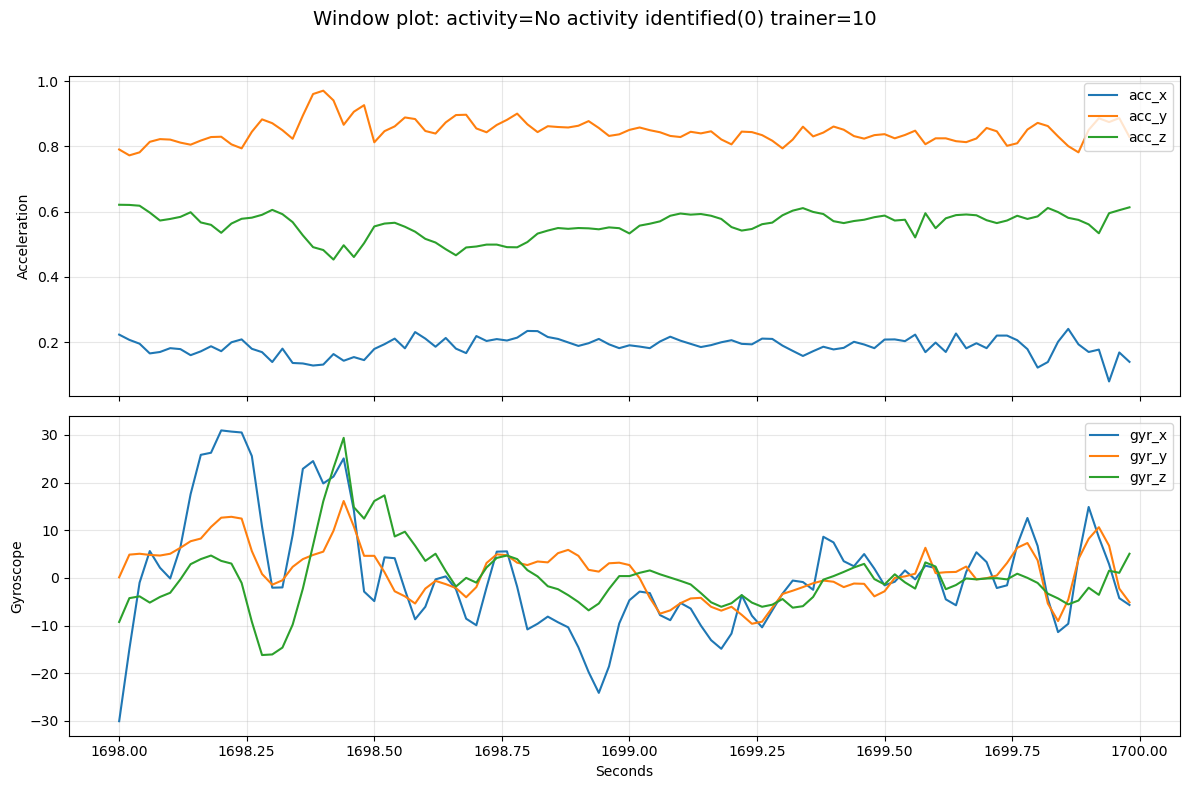

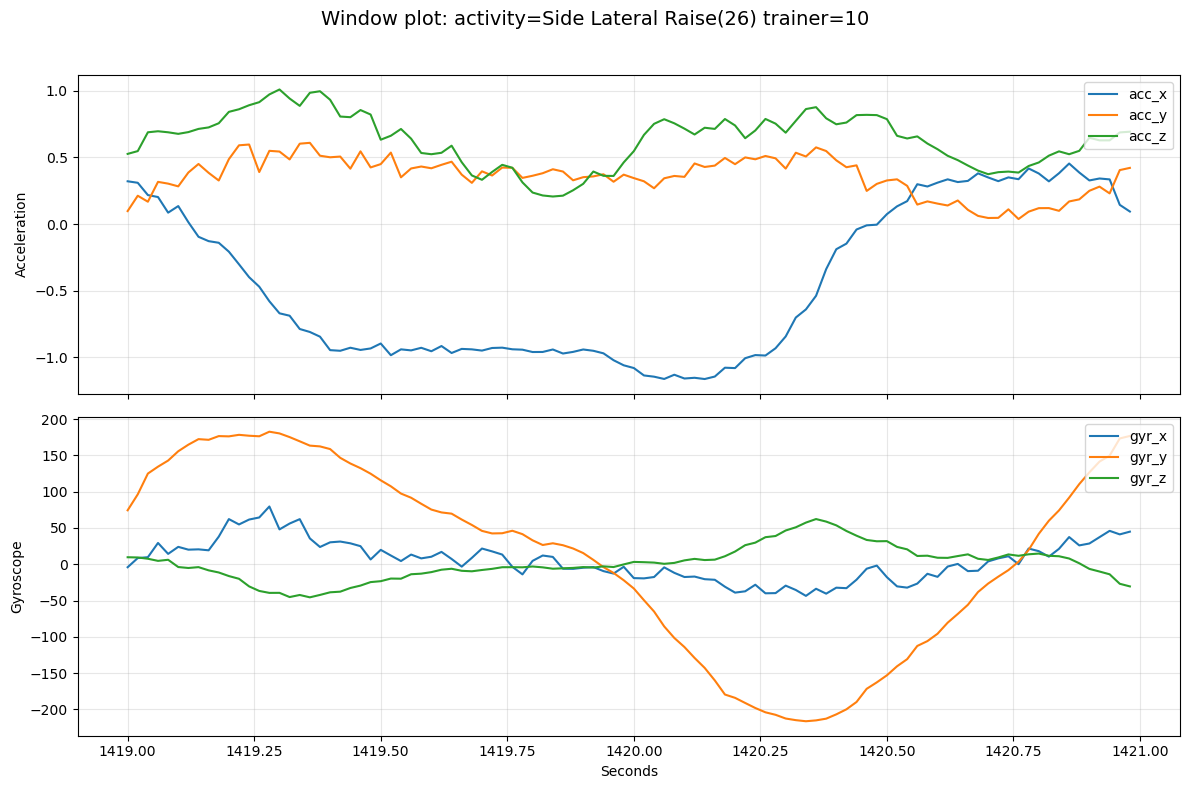

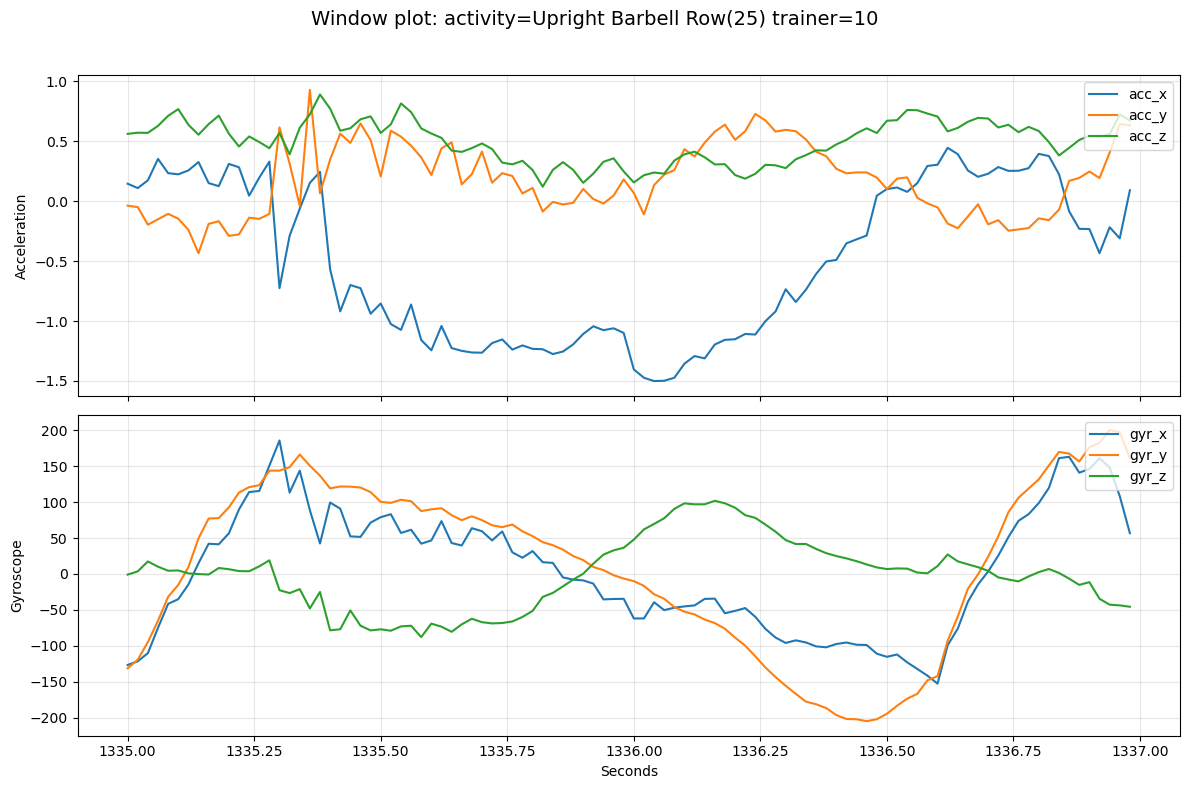

In [ ]:
def plot_random_windows(x, y, t, timestamps, activity_mapping, n=3, seed=123):
    """Plot n random windows from the dataset."""
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(x), size=min(n, len(x)), replace=False)
    for idx in indices:
        plot_window(x[idx], y[idx], t[idx], timestamps[idx], activity_mapping)

plot_random_windows(x, y, t, timestamps, myogym_mapping, n=3, seed=1234)